In [18]:
import os
import json
import re
from pathlib import Path

def build_patient_dictionary(root_paths):

    #root_paths: list of two folder paths, e.g. 
    #    [r"C:\Users\ayw005\Desktop\BENG 280C Project\BENG280C_pacing_lead_data_1st20",
    #     r"C:\Users\ayw005\Desktop\BENG 280C Project\HCT2_lead_segmentation_training"]
    #Returns a dictionary keyed by patient ID, with file paths and ground_truth flag.

    patient_dict = {}
    
    for base_path in root_paths:
        base = Path(base_path)
        
        # Find raw image nii files
        img_dir = base / "HCT2_img_nii"
        seg_dir = base / "HCT2_leads_seg_nii"
        png_dir = base / "HCT2_leads_png"
        png_dir_alt = base / "HCT2_leads_groundtruth_png"  # Alternative name in second folder
        rois_dir = base / "AUH-2024-HCT2-rois"
        
        # Some folders might not exist in the second structure, handle gracefully
        if not img_dir.exists():
            print(f"Warning: {img_dir} not found")
            continue
        
        # Handle both naming patterns: *_HCT2.nii.gz and *_HCT2_img.nii.gz
        img_files = list(img_dir.glob("*_HCT2.nii.gz")) + list(img_dir.glob("*_HCT2_img.nii.gz"))
            
        for img_file in img_files:
            # Extract patient ID from either pattern
            # "10001_HCT2.nii.gz" -> "10001" or "10001_HCT2_img.nii.gz" -> "10001"
            patient_id = re.match(r"^(\d+)", img_file.name).group(1)
            
            # Skip if already added (shouldn't happen, but safety check)
            if patient_id in patient_dict:
                continue
            
            # Initialize entry
            patient_dict[patient_id] = {
                "raw_nii": str(img_file),
                "seg_nii": None,
                "png_folder": None,
                "rois_csv": None,
                "rois_bullseye_csv": None,
                "rois_bullseye_png": None,
                "has_ground_truth": False,
                "source_folder": str(base)
            }
            
            # Find matching segmentation - handle both naming patterns
            # Folder 1: 10001_HCT2_HCT2_leads_seg.nii.gz, Folder 2: 10001_HCT2_leads_seg.nii.gz
            if seg_dir.exists():
                seg_file = seg_dir / f"{patient_id}_HCT2_leads_seg.nii.gz"
                if seg_file.exists():
                    patient_dict[patient_id]["seg_nii"] = str(seg_file)
                    patient_dict[patient_id]["has_ground_truth"] = True
                else:
                    # Try folder 1 pattern with extra _HCT2
                    seg_file_alt = seg_dir / f"{patient_id}_HCT2_HCT2_leads_seg.nii.gz"
                    if seg_file_alt.exists():
                        patient_dict[patient_id]["seg_nii"] = str(seg_file_alt)
                        patient_dict[patient_id]["has_ground_truth"] = True
            
            # Find PNG folder (might be named "10001_HCT2" inside HCT2_leads_png or HCT2_leads_groundtruth_png)
            if png_dir.exists():
                png_subdir = png_dir / f"{patient_id}_HCT2"
                if png_subdir.exists():
                    patient_dict[patient_id]["png_folder"] = str(png_subdir)
            if png_dir_alt.exists() and not patient_dict[patient_id]["png_folder"]:
                png_subdir = png_dir_alt / f"{patient_id}_HCT2"
                if png_subdir.exists():
                    patient_dict[patient_id]["png_folder"] = str(png_subdir)
            
            # Find ROI files (manual ground truth) - handle both with and without leading dot
            if rois_dir.exists():
                # Try pattern without leading dot first (10001_leads.csv)
                csv_file = rois_dir / f"{patient_id}_leads.csv"
                if csv_file.exists():
                    patient_dict[patient_id]["rois_csv"] = str(csv_file)
                    patient_dict[patient_id]["has_ground_truth"] = True
                else:
                    # Try with leading dot (._10001_leads.csv)
                    csv_file_alt = rois_dir / f"._{patient_id}_leads.csv"
                    if csv_file_alt.exists():
                        patient_dict[patient_id]["rois_csv"] = str(csv_file_alt)
                        patient_dict[patient_id]["has_ground_truth"] = True
                
                # Bullseye CSV - try both patterns
                bull_csv = rois_dir / f"{patient_id}_leads_bullseye.csv"
                if bull_csv.exists():
                    patient_dict[patient_id]["rois_bullseye_csv"] = str(bull_csv)
                else:
                    bull_csv_alt = rois_dir / f"._{patient_id}_leads_bullseye.csv"
                    if bull_csv_alt.exists():
                        patient_dict[patient_id]["rois_bullseye_csv"] = str(bull_csv_alt)
                
                # Bullseye PNG - try both patterns
                bull_png = rois_dir / f"{patient_id}_leads_bullseye.png"
                if bull_png.exists():
                    patient_dict[patient_id]["rois_bullseye_png"] = str(bull_png)
                else:
                    bull_png_alt = rois_dir / f"._{patient_id}_leads_bullseye.png"
                    if bull_png_alt.exists():
                        patient_dict[patient_id]["rois_bullseye_png"] = str(bull_png_alt)
    
    return patient_dict

# Usage
root_folders = [r"C:\Users\ayw005\Desktop\BENG 280C Project\BENG280C_pacing_lead_data_1st20",  r"C:\Users\ayw005\Desktop\BENG 280C Project\HCT2_lead_segmentation_training"]   # <--- CHANGE TO YOUR ACTUAL PATHS

patient_dict = build_patient_dictionary(root_folders)

# Save to JSON for later use
with open("patient_data_index.json", "w") as f:
    json.dump(patient_dict, f, indent=2)

print(f"Total patients indexed: {len(patient_dict)}")
ground_truth_count = sum(1 for v in patient_dict.values() if v["has_ground_truth"])
print(f"With ground truth: {ground_truth_count}")
print(f"Without ground truth: {len(patient_dict) - ground_truth_count}")

Total patients indexed: 281
With ground truth: 60
Without ground truth: 221


In [19]:
import nibabel as nib
import numpy as np
from scipy.ndimage import center_of_mass

def get_label_centroids(seg_nii_path, label_list=None):
    """
    Load segmentation NIfTI, compute centroid (voxel) then transform to world coordinates (mm).
    
    Args:
        seg_nii_path: path to .nii.gz segmentation file
        label_list: list of integers, e.g. [4001,4002,4003,4004,4005,4006,4007,4008]
                   If None, returns all unique labels present.
    
    Returns:
        centroids_world: dict {label: (x,y,z) in mm}
        affine: the 4x4 affine matrix
    """
    img = nib.load(seg_nii_path)
    data = img.get_fdata()
    affine = img.affine
    
    if label_list is None:
        label_list = np.unique(data).astype(int).tolist()
        # remove background 0
        label_list = [l for l in label_list if l != 0]
    
    centroids_world = {}
    for label in label_list:
        # Find all voxels with this label
        mask = (data == label)
        if not np.any(mask):
            print(f"Label {label} not found in {seg_nii_path}")
            continue
        
        # Voxel centroid (i,j,k)
        com_vox = center_of_mass(mask)  # returns (z,y,x)? Actually center_of_mass returns order as array dimensions: (dim0, dim1, dim2)
        # Nibabel uses (x,y,z) for affine but data is (z,y,x)? Let's be safe: convert to (i,j,k) indexes
        # center_of_mass returns (r,c,s) where r is first dimension (usually z in medical images)
        # We'll just apply affine to the voxel coordinate as (i,j,k,1)
        # Standard: affine transforms (x,y,z,1) where x = column, y = row, z = slice
        # But our com_vox order depends on how data was loaded. Let's use the proper method:
        # Use nibabel's apply_affine after converting to RAS+ world coordinates.
        # Simpler: get the centroid in voxel space as (x,y,z) by reordering.
        # Data shape is (slices, rows, cols) usually. So:
        #   dim0 = slice (z), dim1 = row (y), dim2 = col (x)
        z, y, x = com_vox
        vox_coord = np.array([x, y, z, 1])   # (x,y,z,1) for affine multiplication
        world_coord = affine @ vox_coord
        centroids_world[label] = world_coord[:3]   # (x,y,z) in mm
    
    return centroids_world, affine

# Example usage on a ground truth patient
example_patient = list(patient_dict.keys())[0]
seg_path = patient_dict[example_patient]["seg_nii"]
if seg_path:
    centroids, _ = get_label_centroids(seg_path)
    print(f"Patient {example_patient} centroids (mm):")
    for label, coord in centroids.items():
        print(f"  Label {label}: ({coord[0]:.2f}, {coord[1]:.2f}, {coord[2]:.2f})")

Patient 10001 centroids (mm):
  Label 4001: (-75.32, 222.78, 273.90)
  Label 4002: (-96.27, 245.42, 248.70)
  Label 4003: (-48.29, 227.85, 397.80)
  Label 4004: (-100.67, 232.92, 403.40)
  Label 4005: (-89.85, 230.56, 429.30)
  Label 4006: (-81.41, 230.89, 437.70)
  Label 4007: (-69.92, 226.84, 448.20)
  Label 4008: (-77.01, 232.92, 225.60)
  Label 4009: (-67.89, 234.61, 226.30)


In [20]:
import pandas as pd

def load_manual_csv(csv_path):
    """Load the manual CSV (with columns like LL1_x, LL1_y, LL1_z)"""
    df = pd.read_csv(csv_path)
    # The format may vary. Usually they have columns: Name, X, Y, Z
    # Or separate columns per coordinate. We'll inspect.
    # Let's assume typical Horos ROI export has rows for each point.
    # If not, you'll need to adapt.
    # I'll write a generic parser based on typical structure.
    points = {}
    # Try to read as long format (Name, X, Y, Z)
    if 'Name' in df.columns and 'X' in df.columns:
        for _, row in df.iterrows():
            points[row['Name']] = (row['X'], row['Y'], row['Z'])
    else:
        # Try wide format: LL1_x, LL1_y, LL1_z
        for col in df.columns:
            if col.endswith('_x'):
                base = col[:-2]
                if f"{base}_y" in df.columns and f"{base}_z" in df.columns:
                    points[base] = (df[col].values[0], df[f"{base}_y"].values[0], df[f"{base}_z"].values[0])
    return points

def calculate_error(extracted_centroids, manual_points, label_to_name_map):
    """
    label_to_name_map: e.g., {4001: 'LL1', 4002: 'LL2', ..., 4007: 'APEX', 4008: 'BASE'}
    """
    errors = {}
    for label, centroid in extracted_centroids.items():
        name = label_to_name_map.get(label)
        if name and name in manual_points:
            manual = manual_points[name]
            dist = np.linalg.norm(np.array(centroid) - np.array(manual))
            errors[name] = dist
    return errors

# Example mapping
label_to_name = {
    4001: 'LL1', 4002: 'LL2', 4003: 'LL3', 4004: 'LL4',
    4005: 'RV1', 4006: 'RV2',
    4007: 'APEX', 4008: 'BASE'
}

# For a patient with both seg and manual CSV
pid = example_patient
if patient_dict[pid]["seg_nii"] and patient_dict[pid]["rois_csv"]:
    centroids, _ = get_label_centroids(patient_dict[pid]["seg_nii"], label_list=list(label_to_name.keys()))
    manual = load_manual_csv(patient_dict[pid]["rois_csv"])
    errors = calculate_error(centroids, manual, label_to_name)
    print(f"Errors for {pid} (mm): {errors}")
    mean_error = np.mean(list(errors.values()))
    print(f"Mean error: {mean_error:.2f} mm")

Errors for 10001 (mm): {}
Mean error: nan mm


c:\Users\austi\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\austi\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


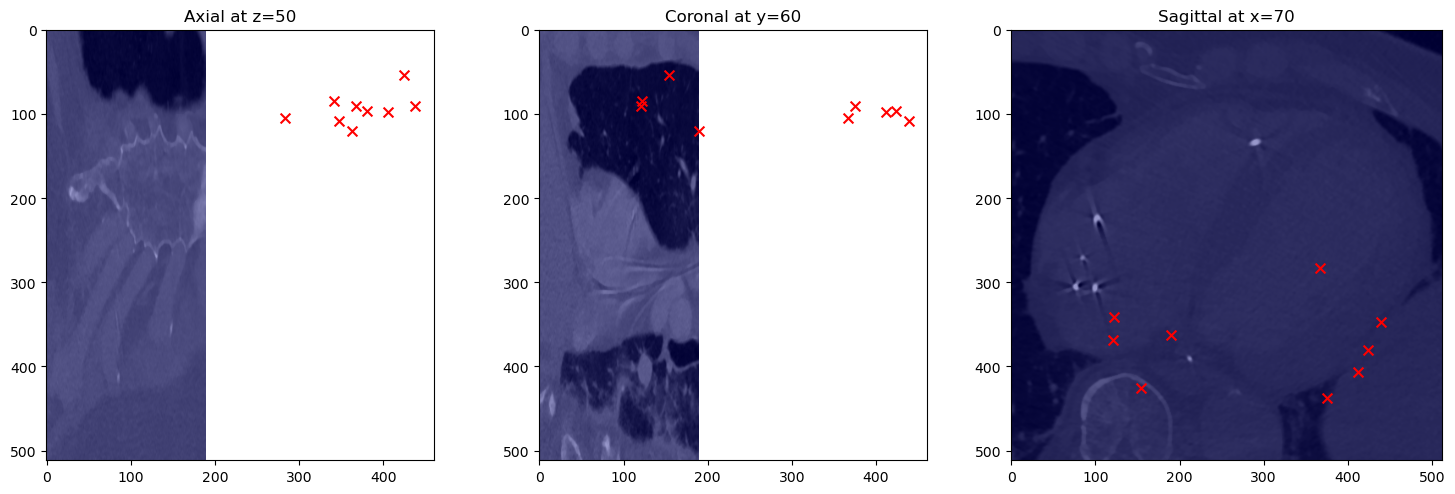

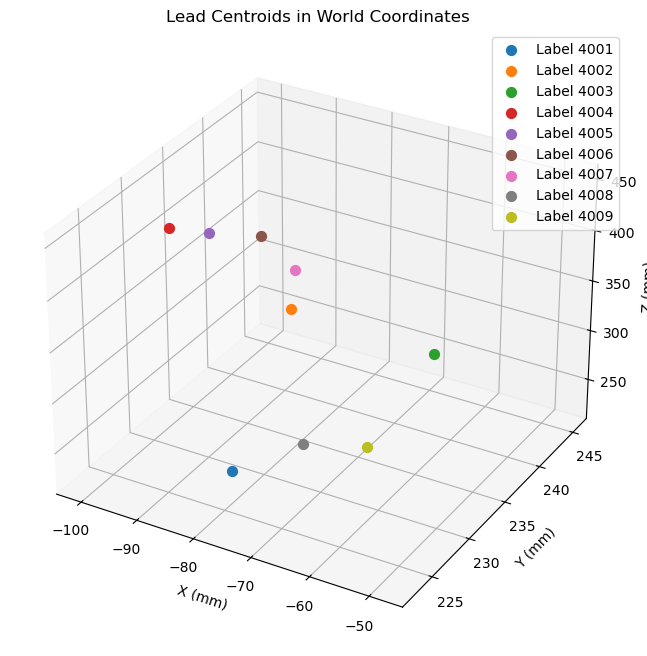

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_3d_slices(ct_nii_path, seg_nii_path=None, centroids=None, slice_indices=[50,60,70]):
    """
    Show three orthogonal slices through the 3D volume with optional segmentation overlay.
    """
    ct_img = nib.load(ct_nii_path)
    ct_data = ct_img.get_fdata()
    
    fig, axes = plt.subplots(1, 3, figsize=(15,5))
    titles = ['Axial (Z)', 'Coronal (Y)', 'Sagittal (X)']
    
    # Get center slices if indices not provided
    if slice_indices is None:
        slice_indices = [ct_data.shape[0]//2, ct_data.shape[1]//2, ct_data.shape[2]//2]
    
    # Axial (z slice)
    axes[0].imshow(ct_data[slice_indices[0], :, :], cmap='gray')
    axes[0].set_title(f'Axial at z={slice_indices[0]}')
    # Coronal (y slice)
    axes[1].imshow(ct_data[:, slice_indices[1], :], cmap='gray')
    axes[1].set_title(f'Coronal at y={slice_indices[1]}')
    # Sagittal (x slice)
    axes[2].imshow(ct_data[:, :, slice_indices[2]], cmap='gray')
    axes[2].set_title(f'Sagittal at x={slice_indices[2]}')
    
    # Overlay segmentation if provided
    if seg_nii_path:
        seg_img = nib.load(seg_nii_path)
        seg_data = seg_img.get_fdata()
        # Create a mask for any non-zero label
        mask = seg_data > 0
        # Overlay with transparency (alpha)
        for i, ax in enumerate(axes):
            if i == 0:
                overlay = mask[slice_indices[0], :, :]
            elif i == 1:
                overlay = mask[:, slice_indices[1], :]
            else:
                overlay = mask[:, :, slice_indices[2]]
            ax.imshow(overlay, cmap='jet', alpha=0.4)
    
    # Plot centroids if provided (convert to voxel coordinates first)
    if centroids:
        # We need the inverse affine to map world -> voxel
        inv_aff = np.linalg.inv(ct_img.affine)
        for label, world_xyz in centroids.items():
            vox = inv_aff @ [world_xyz[0], world_xyz[1], world_xyz[2], 1]
            xv, yv, zv = int(round(vox[0])), int(round(vox[1])), int(round(vox[2]))
            # Plot in each slice if it passes through
            # For simplicity, we just mark in all three views
            axes[0].scatter(yv, xv, color='red', s=50, marker='x')  # yv is column, xv is row? Adjust based on orientation
            axes[1].scatter(zv, xv, color='red', s=50, marker='x')
            axes[2].scatter(zv, yv, color='red', s=50, marker='x')
    
    plt.tight_layout()
    plt.show()

# Example: visual check for one patient
pid = example_patient
raw_path = patient_dict[pid]["raw_nii"]
seg_path = patient_dict[pid]["seg_nii"]
if seg_path:
    centroids, _ = get_label_centroids(seg_path)
    plot_3d_slices(raw_path, seg_path, centroids)

def plot_3d_scatter(ct_nii_path, centroids):
    ct_img = nib.load(ct_nii_path)
    data = ct_img.get_fdata()
    # Create a meshgrid for the bounding box (optional)
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the centroid points
    for label, (x,y,z) in centroids.items():
        ax.scatter(x, y, z, s=50, label=f'Label {label}')
    
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_zlabel('Z (mm)')
    ax.legend()
    plt.title('Lead Centroids in World Coordinates')
    plt.show()

# Usage
plot_3d_scatter(raw_path, centroids)

import torch
import torch.nn as nn
from monai.networks.nets import DenseNet121
from monai.transforms import LoadImage, EnsureChannelFirst, Compose, ScaleIntensity, RandRotate, RandZoom
from monai.data import Dataset, DataLoader

# This is just a sketch – you'll need to adapt to your actual data size
# But I strongly advise you to first try classical methods before ML.

# Classical method for lead detection (no training):
def detect_leads_by_threshold(raw_nii_path, hu_threshold=2000, min_volume_mm3=5):
    """
    Simple threshold-based lead detection.
    Returns list of centroids in mm for all blobs above threshold.
    """
    import nibabel as nib
    from skimage import measure
    img = nib.load(raw_nii_path)
    data = img.get_fdata()
    affine = img.affine
    
    # Threshold for metal
    binary = (data > hu_threshold).astype(np.uint8)
    # Connected components
    labeled = measure.label(binary, connectivity=2)
    props = measure.regionprops(labeled)
    
    # Filter by volume (convert voxels to mm^3)
    vox_vol = np.prod(img.header.get_zooms())  # voxel volume in mm^3
    centroids = []
    for prop in props:
        if prop.area * vox_vol >= min_volume_mm3:
            # Centroid in voxel coordinates
            cy, cx, cz = prop.centroid  # careful: order might be (z,y,x)
            vox_coord = np.array([cx, cy, cz, 1])
            world = affine @ vox_coord
            centroids.append(world[:3])
    return centroids

# Try this on a patient and compare to ground truth segmentation centroids
# Often this works surprisingly well for bright leads.